In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

sales    = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv')
calendar = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')
calendar["date"] = pd.to_datetime(calendar["date"])

day_cols    = [c for c in sales.columns if c.startswith("d_")]
day_to_date = dict(zip(calendar["d"], calendar["date"]))

print("Tendances des ventes :", sales.shape)
print("Magasins :", sales["store_id"].unique())
print("Events disponibles :", calendar["event_name_1"].dropna().unique())

Tendances des ventes : (30490, 1947)
Magasins : ['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']
Events disponibles : ['SuperBowl' 'ValentinesDay' 'PresidentsDay' 'LentStart' 'LentWeek2'
 'StPatricksDay' 'Purim End' 'OrthodoxEaster' 'Pesach End' 'Cinco De Mayo'
 "Mother's day" 'MemorialDay' 'NBAFinalsStart' 'NBAFinalsEnd'
 "Father's day" 'IndependenceDay' 'Ramadan starts' 'Eid al-Fitr'
 'LaborDay' 'ColumbusDay' 'Halloween' 'EidAlAdha' 'VeteransDay'
 'Thanksgiving' 'Christmas' 'Chanukah End' 'NewYear' 'OrthodoxChristmas'
 'MartinLutherKingDay' 'Easter']


On passe aux ventes totales par jour sur tous les magasins 

In [3]:

total_daily = pd.Series(
    sales[day_cols].sum().values,
    index=[day_to_date[d] for d in day_cols]
).sort_index()

# on fait la moyenne globale de référence (baseline) pour savoir 
# est-ce que ce jour est exceptionnel pour tout Walmart ?
baseline = total_daily.mean()

print(f"Nombre de jours : {len(total_daily)}")
print(f"Période : {total_daily.index.min()} : {total_daily.index.max()}")
print(f"Moyenne globale : {baseline:.0f} ventes/jour")

Nombre de jours : 1941
Période : 2011-01-29 00:00:00 : 2016-05-22 00:00:00
Moyenne globale : 34481 ventes/jour


ventes moyennes par mois 

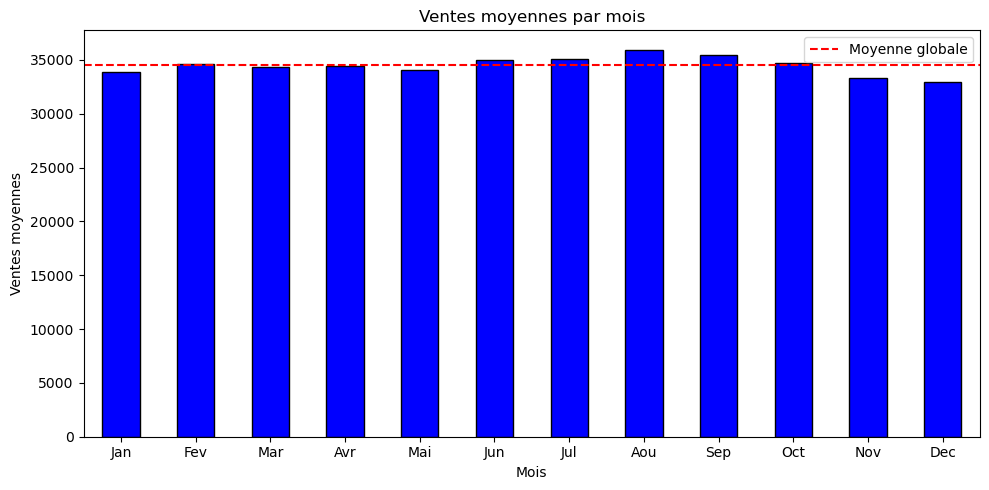

Mois le plus fort : Aou
Mois le plus faible : Dec


In [4]:
ventes_par_mois = total_daily.groupby(total_daily.index.month).mean()

mois_labels = ["Jan", "Fev", "Mar", "Avr", "Mai", "Jun",
               "Jul", "Aou", "Sep", "Oct", "Nov", "Dec"]

ventes_par_mois.index = mois_labels

ventes_par_mois.plot(kind="bar", color="blue", 
                     edgecolor="black", figsize=(10, 5))
plt.title("Ventes moyennes par mois")
plt.xlabel("Mois")
plt.ylabel("Ventes moyennes")
plt.axhline(baseline, color="red", linestyle="--", label="Moyenne globale")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print("Mois le plus fort :", mois_labels[ventes_par_mois.argmax()])
print("Mois le plus faible :", mois_labels[ventes_par_mois.argmin()])

# Ce que je peux en déduire: 
Les ventes sont très stables d'un mois à l'autre. 
Toutes les barres sont proches de la moyenne globale. Il n'y a pas de grosse saisonnalité mensuelle.
Cependant, Août et Septembre sont les mois les plus forts. 
En effet, c'est la rentrée scolaire aux États-Unis ce qui peut expliquer le fait que les gens achètent plus pour préparer la rentrée (hypothèse)
Tandis que Novembre et Décembre sont les plus faibles. Alors ici je me dis que c'est contre-intuitif car on penserait à Noël. Mais ça confirme ce que j'avais trouvé dans mon analyse du rapport de mi-projet : l'effet Noël n'existe pas dans la grande distribution générale car les magasins Walmart sont fermés le 25 décembre donc les ventes chutent.
# De façon générale sur les events: 
La saisonnalité mensuelle est faible donc ce ne sont pas les mois qui expliquent les pics de ventes. Ce sont les events ponctuels qui créent les vraies variations. C'est exactement pour ça qu'on va analyser les events dans les prochaines cellules.

## Analyse des évènements 

Certains événements comme Noël ou Thanksgiving nécessitent
une fenêtre plus large car les gens anticipent leurs achats
plusieurs semaines à l'avance.

Les autres événements ont un impact plus court et ponctuel,
une fenêtre de J-7 à J+7 est suffisante.

In [7]:
# events où les gens anticipent longtemps à l'avance avec une fenêtre J-28 à J+7
events_longs = {
    "Christmas"   : list(range(-28, 8)),
    "Thanksgiving": list(range(-28, 8)),
    "Halloween"   : list(range(-28, 8)),
    "NewYear"     : list(range(-28, 8)),
    "Chanukah End": list(range(-28, 8))
}

# tous les autres events avec une fenêtre J-7 à J+7
events_courts = {
    "SuperBowl"        : list(range(-7, 8)),
    "ValentinesDay"    : list(range(-7, 8)),
    "PresidentsDay"    : list(range(-7, 8)),
    "LentStart"        : list(range(-7, 8)),
    "StPatricksDay"    : list(range(-7, 8)),
    "OrthodoxEaster"   : list(range(-7, 8)),
    "Cinco De Mayo"    : list(range(-7, 8)),
    "Mother's day"     : list(range(-7, 8)),
    "MemorialDay"      : list(range(-7, 8)),
    "NBAFinalsStart"   : list(range(-7, 8)),
    "NBAFinalsEnd"     : list(range(-7, 8)),
    "Father's day"     : list(range(-7, 8)),
    "IndependenceDay"  : list(range(-7, 8)),
    "LaborDay"         : list(range(-7, 8)),
    "ColumbusDay"      : list(range(-7, 8)),
    "VeteransDay"      : list(range(-7, 8)),
    "EidAlAdha"        : list(range(-7, 8)),
    "Eid al-Fitr"      : list(range(-7, 8)),
    "Ramadan starts"   : list(range(-7, 8)),
    "MartinLutherKingDay": list(range(-7, 8)),
    "Easter"           : list(range(-7, 8)),
    "OrthodoxChristmas": list(range(-7, 8)),
    "Purim End"        : list(range(-7, 8)),
    "Pesach End"       : list(range(-7, 8)),
    "LentWeek2"        : list(range(-7, 8))
}

# on fusionne les deux dictionnaires
tous_les_events = {**events_courts, **events_longs}

print(f"Nombre total d events à analyser : {len(tous_les_events)}")
print("Events avec fenêtre longue (J-28) :", list(events_longs.keys()))
print("Events avec fenêtre courte (J-7)  :", list(events_courts.keys()))

Nombre total d events à analyser : 30
Events avec fenêtre longue (J-28) : ['Christmas', 'Thanksgiving', 'Halloween', 'NewYear', 'Chanukah End']
Events avec fenêtre courte (J-7)  : ['SuperBowl', 'ValentinesDay', 'PresidentsDay', 'LentStart', 'StPatricksDay', 'OrthodoxEaster', 'Cinco De Mayo', "Mother's day", 'MemorialDay', 'NBAFinalsStart', 'NBAFinalsEnd', "Father's day", 'IndependenceDay', 'LaborDay', 'ColumbusDay', 'VeteransDay', 'EidAlAdha', 'Eid al-Fitr', 'Ramadan starts', 'MartinLutherKingDay', 'Easter', 'OrthodoxChristmas', 'Purim End', 'Pesach End', 'LentWeek2']


## Calcul de l'impact de tous les événements sur les ventes globales

Pour chaque événement on calcule la variation des ventes
par rapport à la moyenne globale sur la fenêtre définie.

In [12]:
def impact_event(nom_event, offsets):
    
    # on récupère les dates de l event
    dates = calendar[calendar["event_name_1"] == nom_event]["date"].tolist()
    print(f"{nom_event} : {len(dates)} occurrences")
    
    # pour chaque offset on calcule la variation, l'offset me dit à quel jour correspond chaque variation.
    variations = []
    for offset in offsets:
        ventes = []
        for date in dates:
            date_cible = date + pd.Timedelta(days=offset)
            if date_cible in total_daily.index:
                ventes.append(total_daily[date_cible])
        if ventes:
            variations.append((np.mean(ventes) / baseline - 1) * 100)
        else:
            variations.append(0)
    
    return variations

## Analyse de l'impact des événements sur les ventes

Pour chaque événement, nous calculons la variation des ventes 
par rapport à la moyenne globale sur une fenêtre de J-7 à J+7 
(ou J-28 à J+7 pour les événements anticipés longtemps à l'avance 
comme Noël ou Thanksgiving).

Le nombre d'occurrences indique sur combien d'années l'événement 
a été observé dans le dataset. Plus ce nombre est élevé, plus 
le résultat est fiable car il est calculé sur plusieurs années.

Par exemple Easter on a 5 occurrences ce qui signifie que le pic observé 
est une moyenne sur 5 années consécutives. C'est donc un pattern 
reproductible et prévisible, ce qui justifie son intégration 
dans notre modèle de prévision.

In [13]:
resultats_globaux = {}

for event, offsets in tous_les_events.items():
    variations = impact_event(event, offsets)
    resultats_globaux[event] = {
        "variations" : variations,
        "offsets"    : offsets
    }

SuperBowl : 6 occurrences
ValentinesDay : 6 occurrences
PresidentsDay : 6 occurrences
LentStart : 6 occurrences
StPatricksDay : 6 occurrences
OrthodoxEaster : 5 occurrences
Cinco De Mayo : 5 occurrences
Mother's day : 6 occurrences
MemorialDay : 6 occurrences
NBAFinalsStart : 6 occurrences
NBAFinalsEnd : 6 occurrences
Father's day : 4 occurrences
IndependenceDay : 5 occurrences
LaborDay : 5 occurrences
ColumbusDay : 5 occurrences
VeteransDay : 5 occurrences
EidAlAdha : 5 occurrences
Eid al-Fitr : 5 occurrences
Ramadan starts : 6 occurrences
MartinLutherKingDay : 5 occurrences
Easter : 5 occurrences
OrthodoxChristmas : 5 occurrences
Purim End : 6 occurrences
Pesach End : 6 occurrences
LentWeek2 : 6 occurrences
Christmas : 5 occurrences
Thanksgiving : 5 occurrences
Halloween : 5 occurrences
NewYear : 5 occurrences
Chanukah End : 5 occurrences


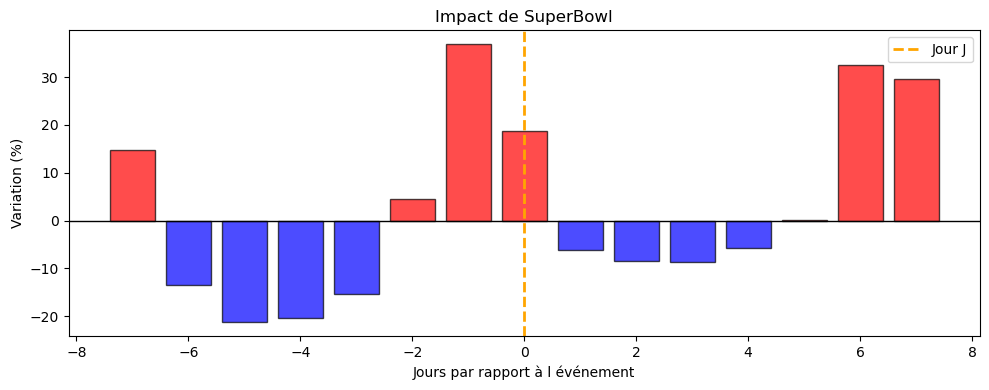

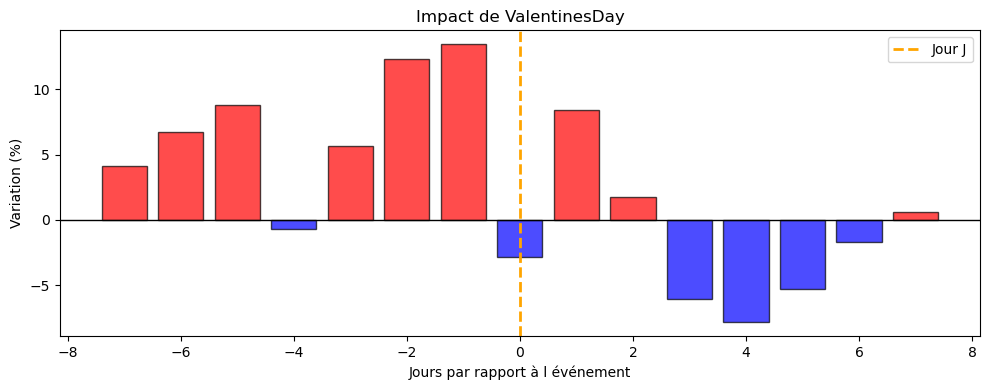

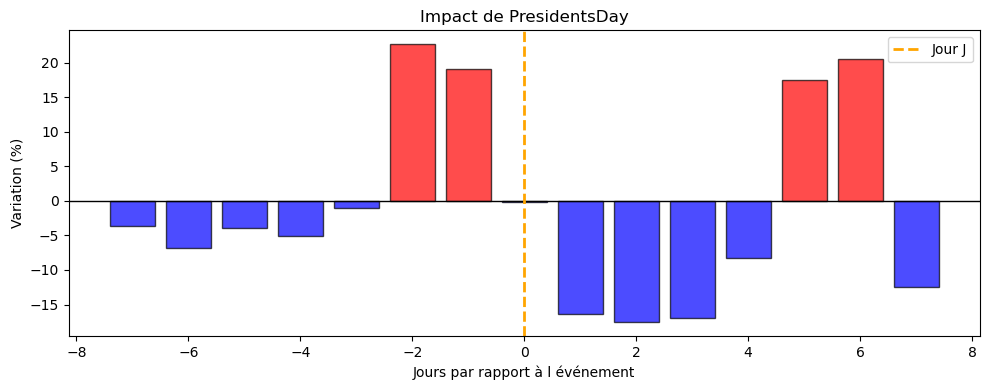

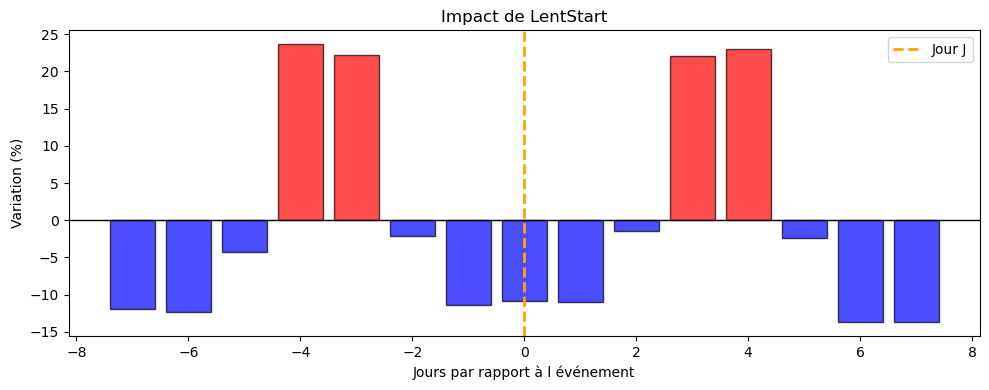

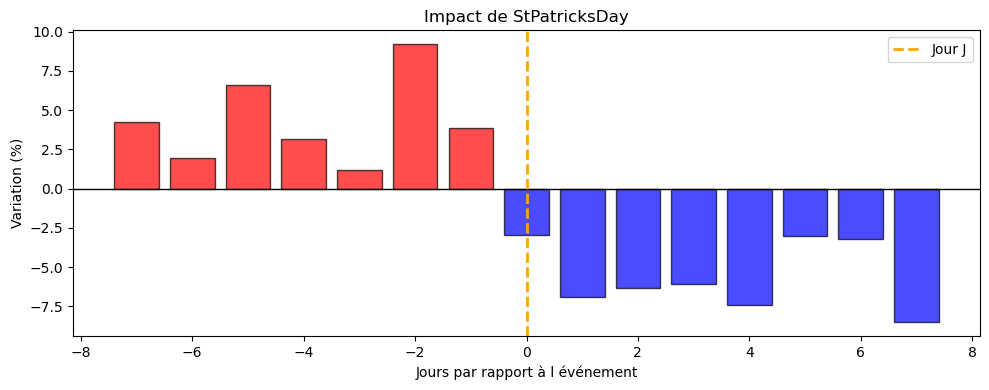

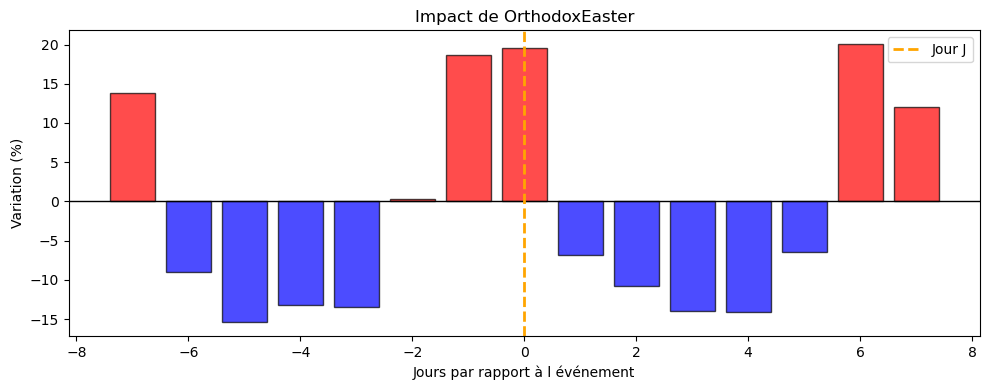

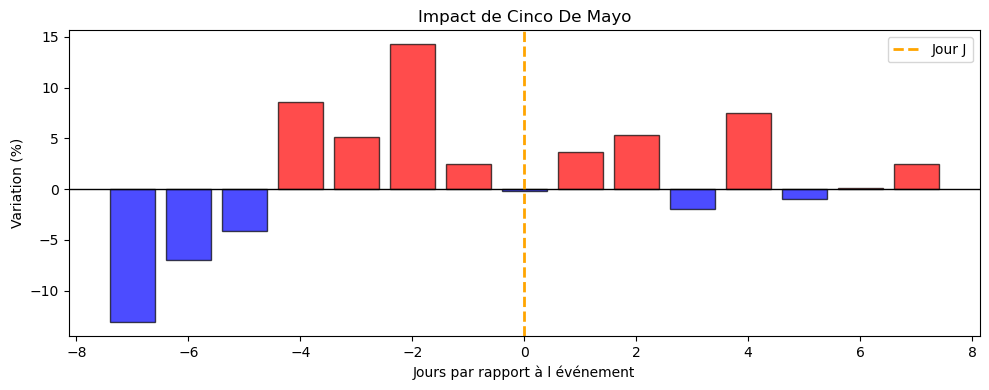

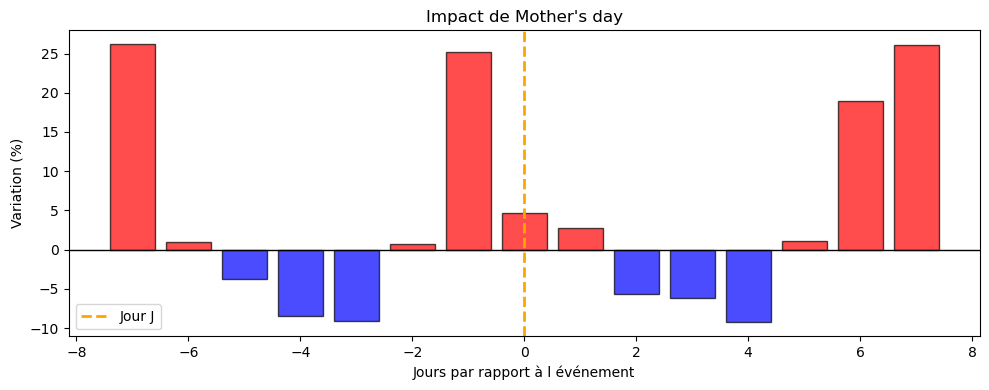

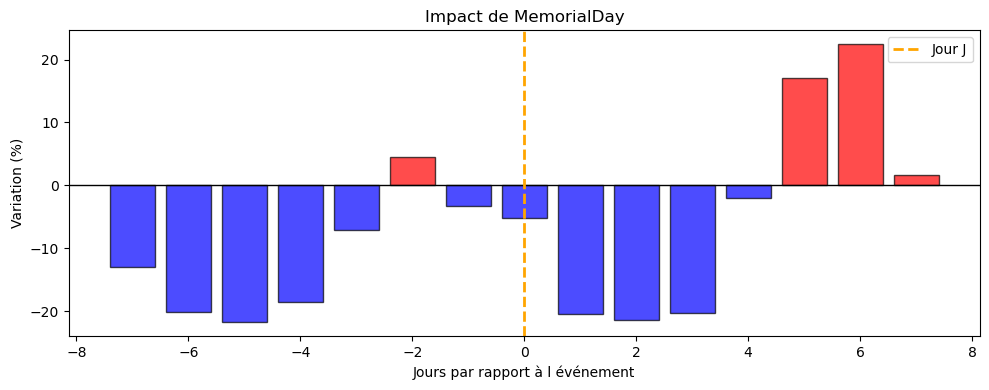

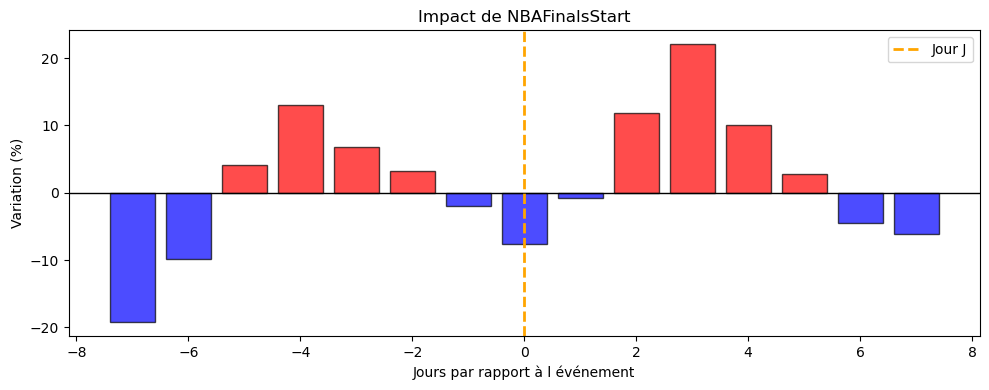

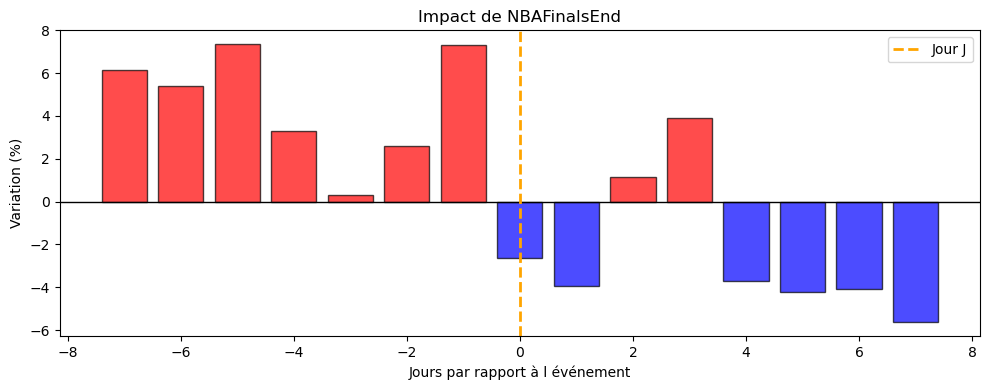

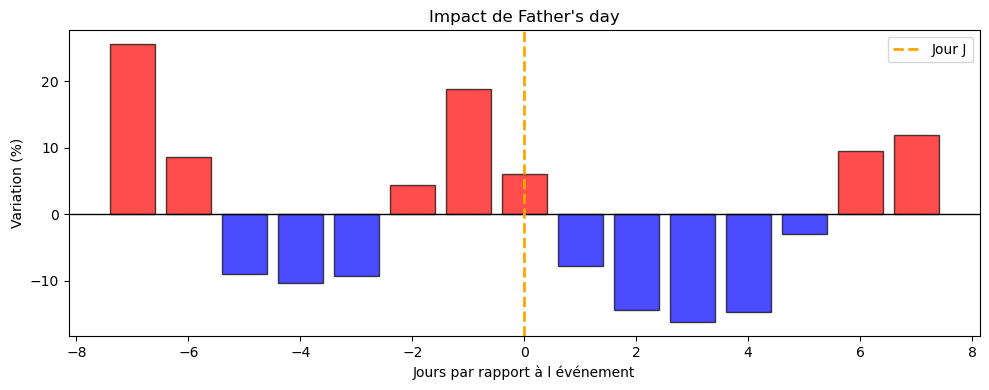

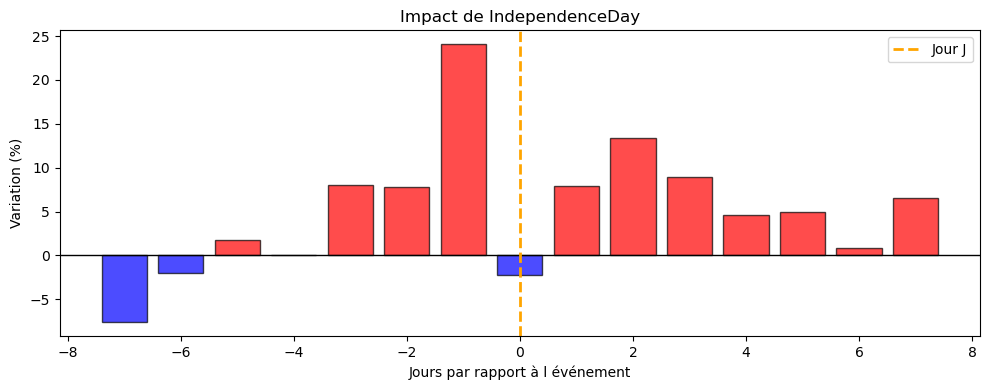

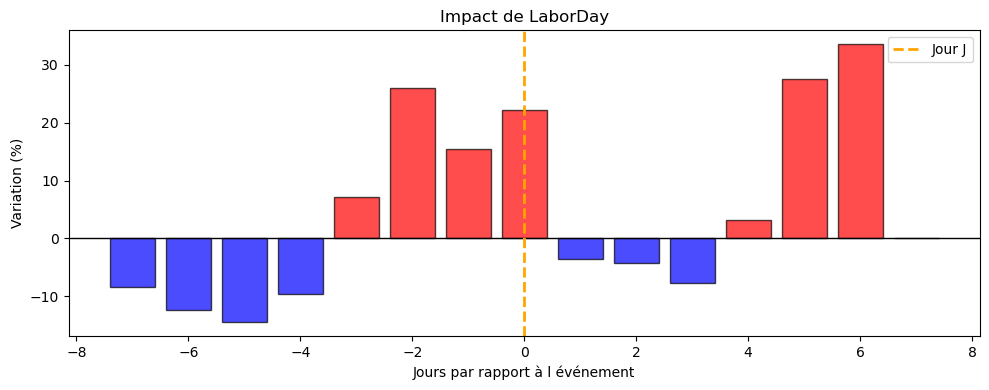

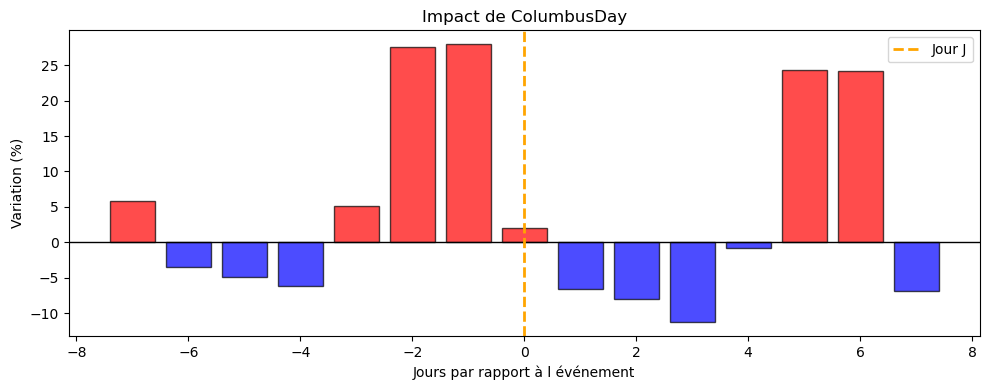

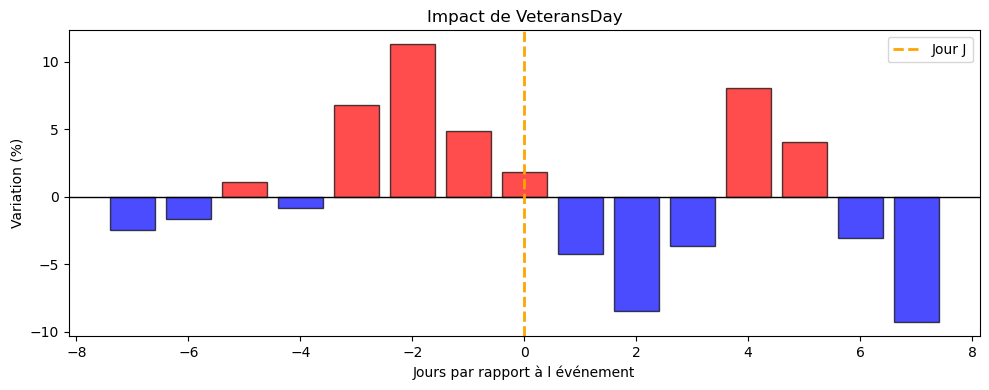

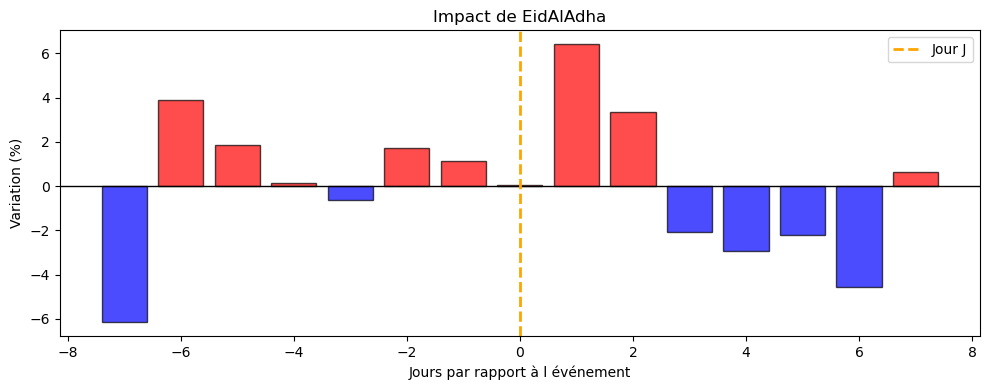

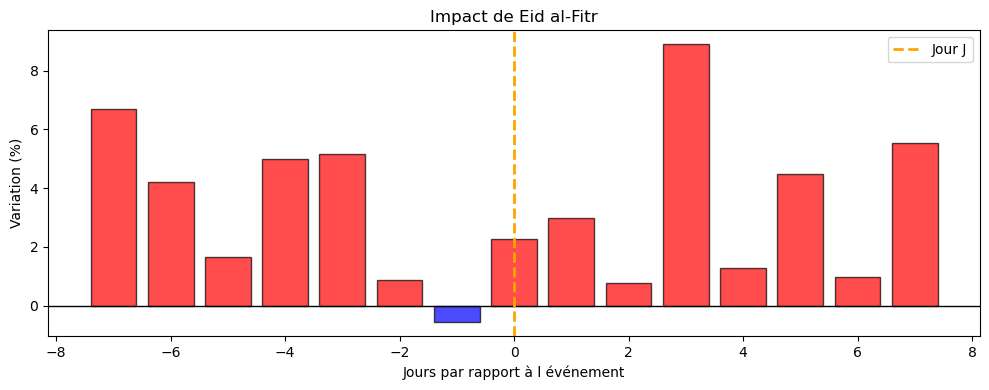

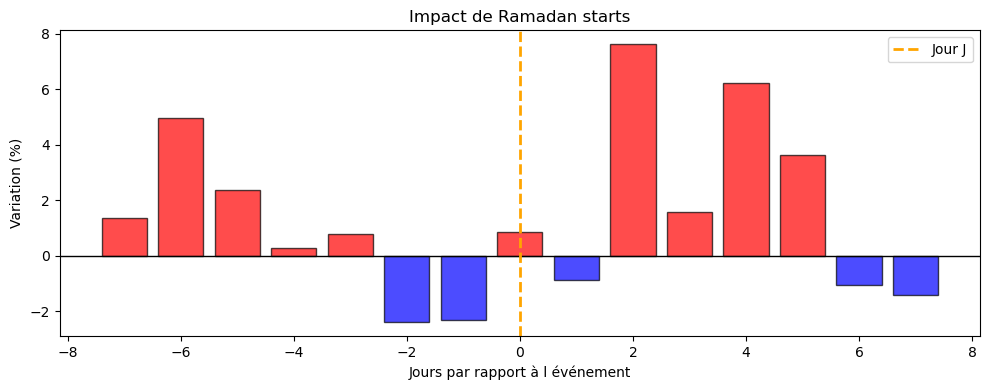

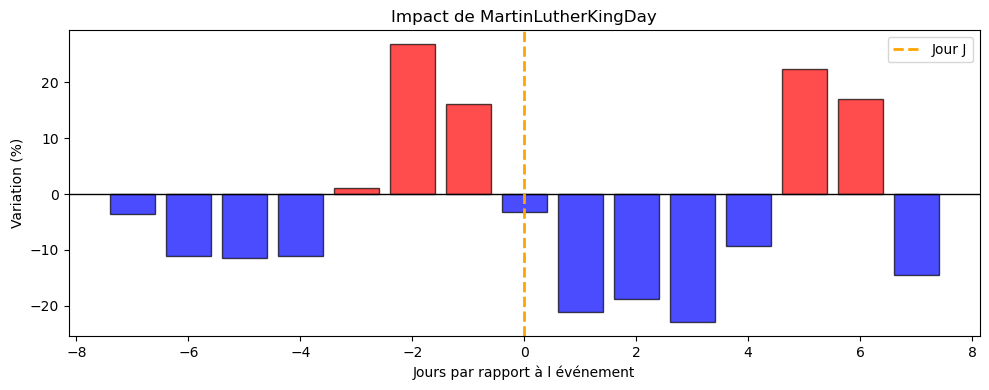

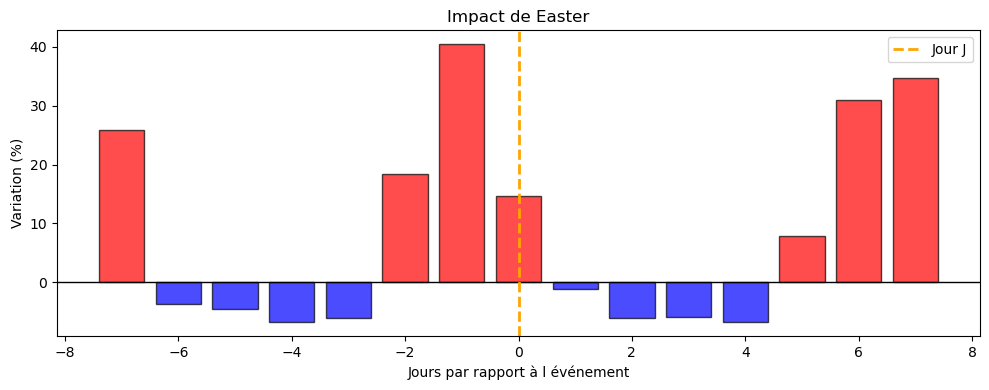

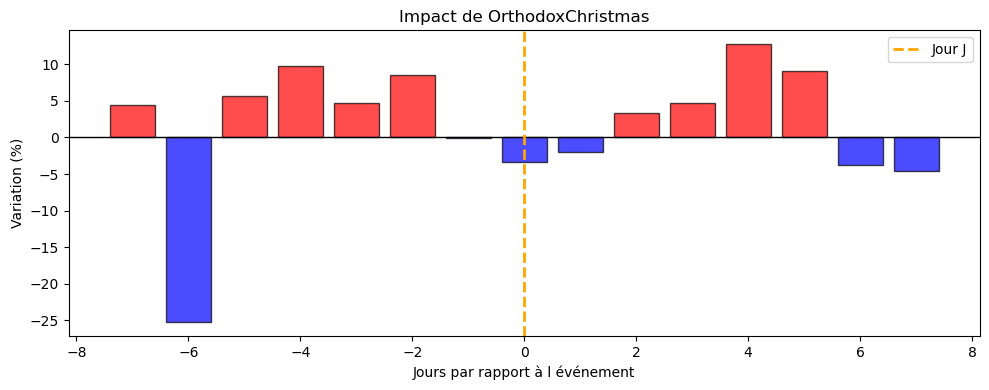

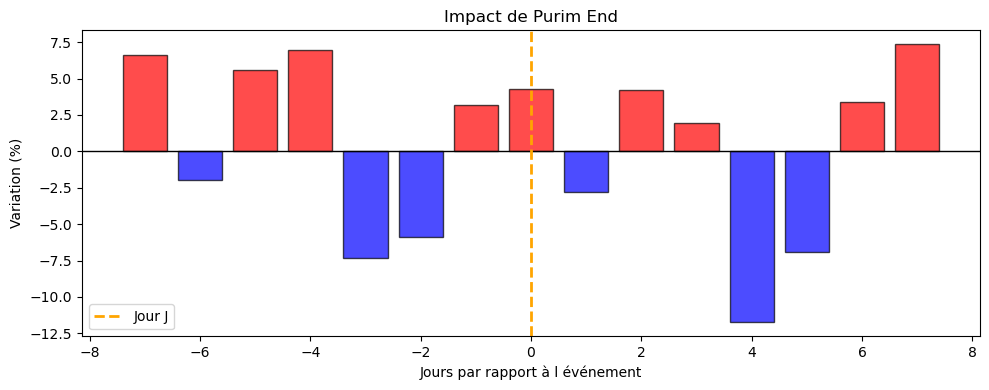

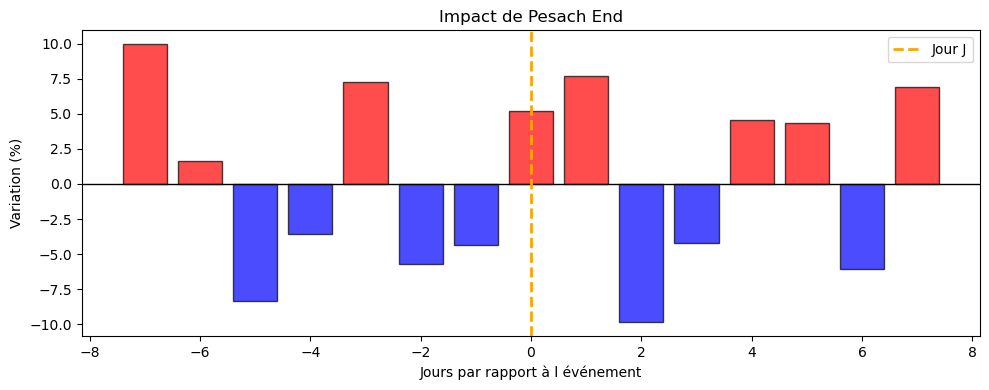

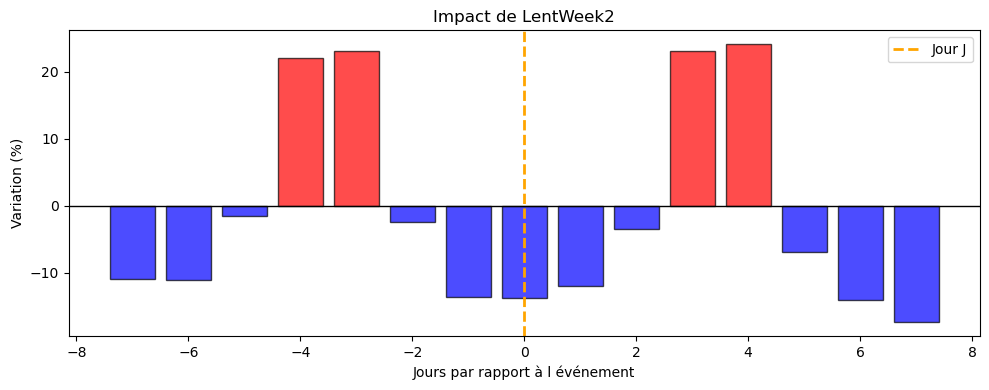

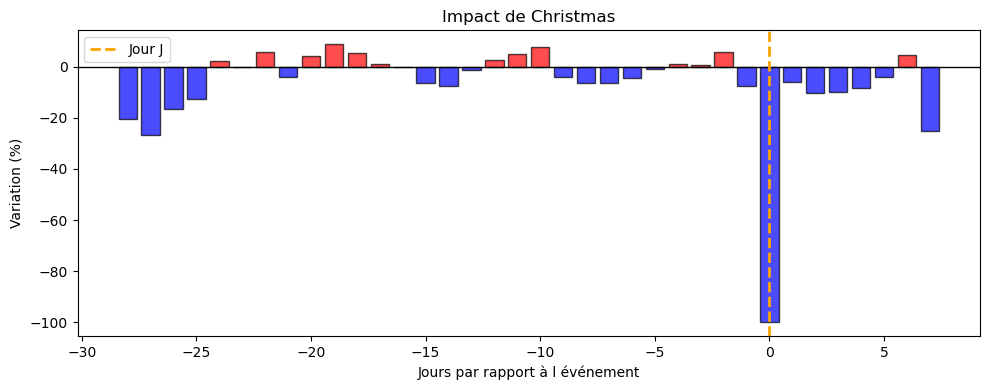

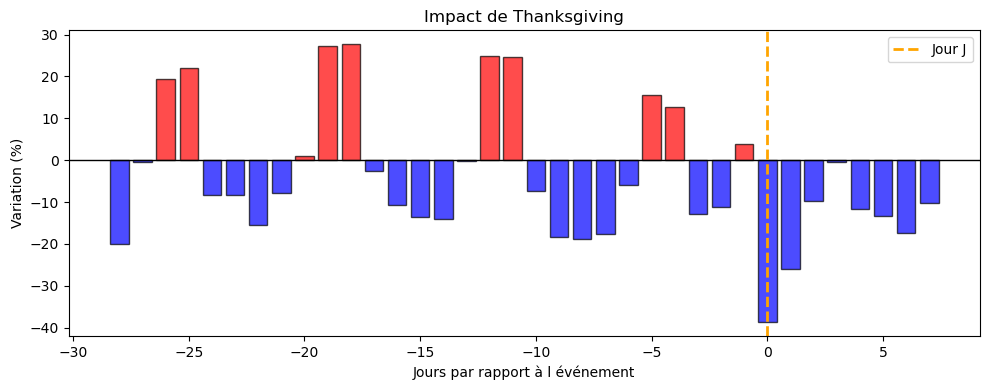

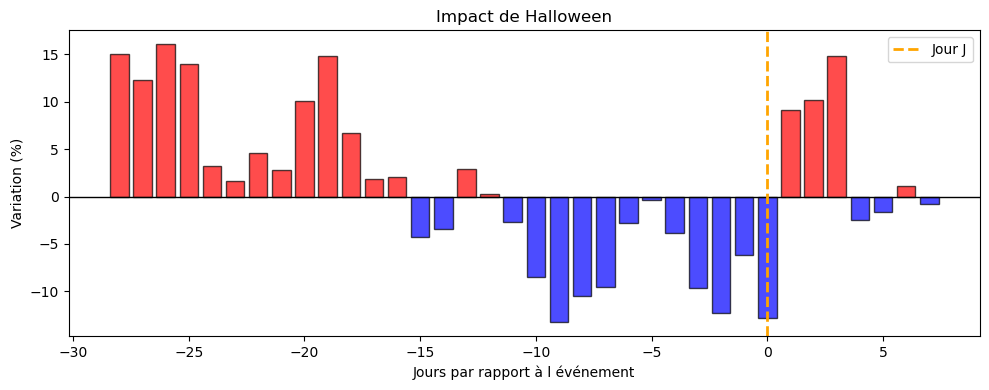

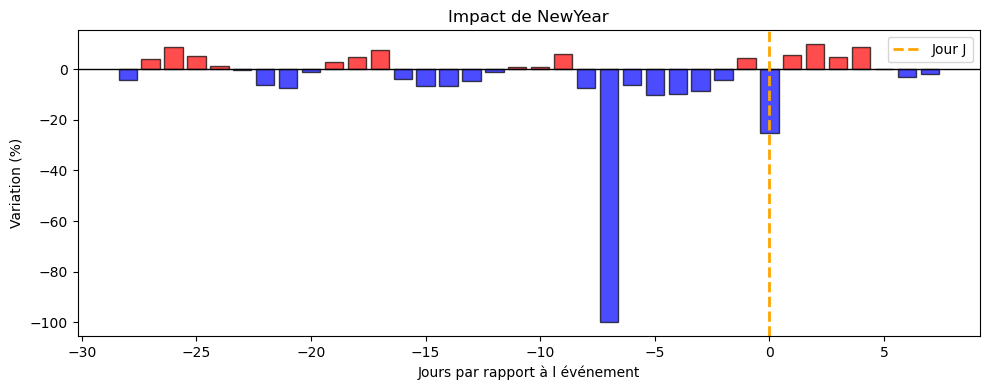

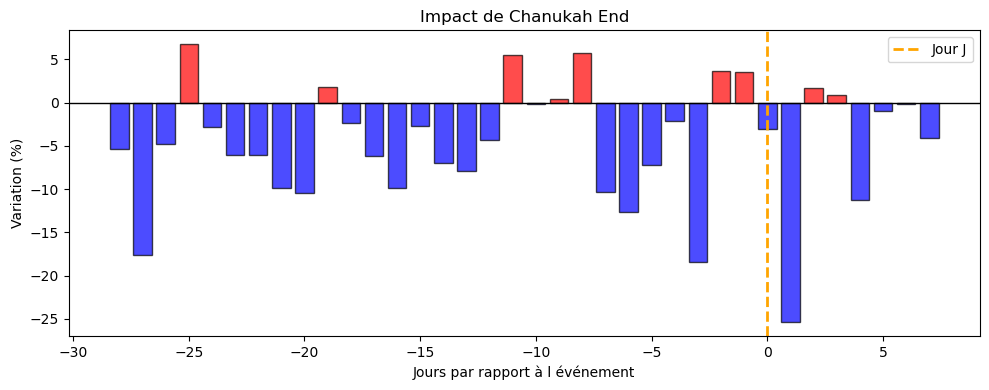

In [16]:
for event, data in resultats_globaux.items():
    offsets    = data["offsets"]
    variations = data["variations"]

    couleurs = ["red" if v > 0 else "blue" for v in variations]

    plt.figure(figsize=(10, 4))
    plt.bar(offsets, variations, color=couleurs, edgecolor="black", alpha=0.7)
    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="orange", linewidth=2, linestyle="--", label="Jour J")
    plt.title(f"Impact de {event}")
    plt.xlabel("Jours par rapport à l événement")
    plt.ylabel("Variation (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Events à fort impact 

- Easter (+40% à J-1)==> pic le plus fort, courses le samedi avant Pâques → stocker max la veille
- SuperBowl (+35% à J-1) ==> achats nourriture/boissons pour la soirée → stocker max la veille
- LaborDay (+33% de J-2 à J+6) ==> long weekend, achats étalés → maintenir les stocks toute la semaine
- Thanksgiving (-40% à J0)==> fermeture tôt mais pics par vagues à J-20, J-10, J-5 → stocker 3 semaines avant, réduire le jour J
- Halloween (pics entre J-28 et J-25)==> event le plus anticipé, achats un mois avant → stocker tôt, liquider après
- Christmas (-100% à J0)==> Walmart fermé le 25 décembre → ne pas sur-stocker, anticiper la fermeture

# Events impact moyen

- ValentinesDay (+13% à J-1)==> achats dernière minute
- PresidentsDay (+22% à J-2)==> weekend prolongé
- MartinLutherKingDay (+25% à J-2)==> weekend prolongé
- ColumbusDay (+27% à J-2)==> weekend prolongé
- IndependenceDay (+24% à J-1)==> barbecues du 4 juillet
- Mother's day (+25% à J-7)==> anticipation une semaine avant
- Father's day (+25% à J-7)==> même pattern que Mother's day

# Events faible impact ==> peu pertinents

- EidAlAdha, Eid al-Fitr, Ramadan==> moins de 10% de variation
- OrthodoxChristmas, Purim End, Pesach End==> impact faible
- Chanukah End==> impact négatif dominant
- NewYear==>la chute visible est due à Christmas dans la fenêtre

## Analyse des performances par magasin

Après avoir analysé l'impact des événements sur les ventes globales,
nous allons maintenant descendre à l'échelle du magasin.

L'objectif est d'identifier :
- Quels magasins surperforment ou sous-performent
- Quels magasins sont stables ou instables
- Comment chaque magasin réagit aux événements

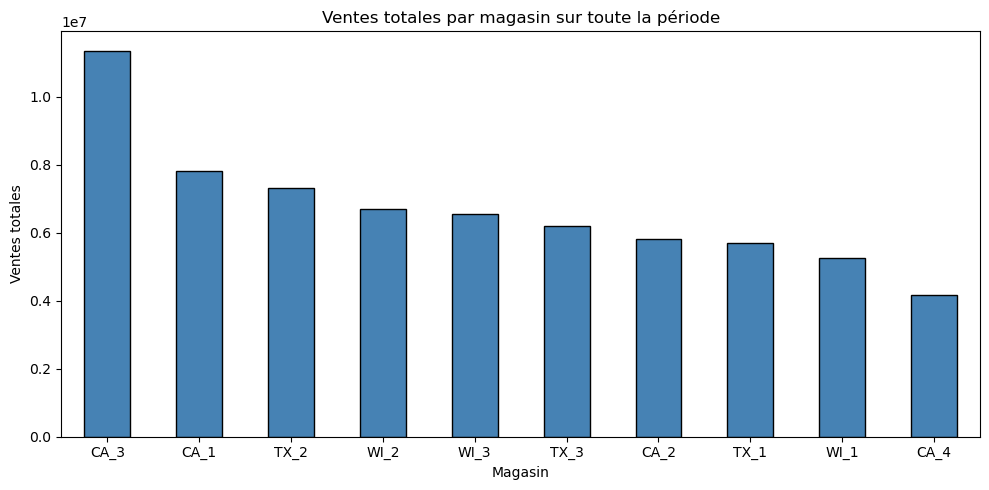


Ventes totales par magasin :
store_id
CA_3    11363540
CA_1     7832248
TX_2     7329642
WI_2     6697988
WI_3     6542557
TX_3     6205940
CA_2     5818395
TX_1     5692823
WI_1     5261506
CA_4     4182534
dtype: int64


In [17]:
# ventes journalières par magasin
stores     = sales["store_id"].unique()
day_cols   = [c for c in sales.columns if c.startswith("d_")]

# total des ventes par magasin sur toute la période
total_par_magasin = sales.groupby("store_id")[day_cols].sum().sum(axis=1)
total_par_magasin = total_par_magasin.sort_values(ascending=False)


total_par_magasin.plot(kind="bar", color="steelblue", 
                       edgecolor="black", figsize=(10, 5))
plt.title("Ventes totales par magasin sur toute la période")
plt.xlabel("Magasin")
plt.ylabel("Ventes totales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nVentes totales par magasin :")
print(total_par_magasin)

## Analyse des performances par magasin

Les performances globales par magasin ont été analysées en détail 
dans notre rapport de mi-projet (section 7.3). Les principaux résultats étaient :

- CA_3 est le magasin le plus performant avec 2,3 millions de ventes en 2014
- CA_4 et WI_1 sont les moins performants
- Les magasins sont positivement corrélés entre eux (0.294 à 0.907)
- Les disparités reflètent des dynamiques géographiques propres à chaque état

Nous allons ici approfondir cette analyse en étudiant comment 
chaque magasin réagit aux événements commerciaux, 
`

## Impact des événements par magasin

Pour chaque événement clé, on analyse comment chaque magasin 
réagit par rapport à sa propre moyenne habituelle.

Cela permet d'identifier :
- Les magasins les plus sensibles aux événements
- Si tous les magasins réagissent de la même façon ou pas

In [21]:
# ventes journalières par magasin
daily_by_store = {}

for store in sales["store_id"].unique():
    ventes_store = sales[sales["store_id"] == store][day_cols].sum()
    daily_by_store[store] = pd.Series(
        ventes_store.values,
        index=[day_to_date[d] for d in day_cols]
    ).sort_index()

print("Magasins chargés :", list(daily_by_store.keys()))

Magasins chargés : ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


### Fonction de calcul de l'impact par magasin

On réutilise la même logique que pour l'analyse globale
mais cette fois on compare chaque magasin à sa propre moyenne.

In [22]:
def impact_event_magasin(store, nom_event, offsets):
    serie    = daily_by_store[store]
    baseline = serie.mean()
    dates    = calendar[calendar["event_name_1"] == nom_event]["date"].tolist()

    variations = []
    for offset in offsets:
        ventes = []
        for date in dates:
            date_cible = date + pd.Timedelta(days=offset)
            if date_cible in serie.index:
                ventes.append(serie[date_cible])
        if ventes:
            variations.append((np.mean(ventes) / baseline - 1) * 100)
        else:
            variations.append(0)

    return variations

### Comparaison des magasins pour les 5 events clés

Pour chaque événement, on superpose les courbes de tous les magasins
pour voir si ils réagissent de la même façon ou pas.

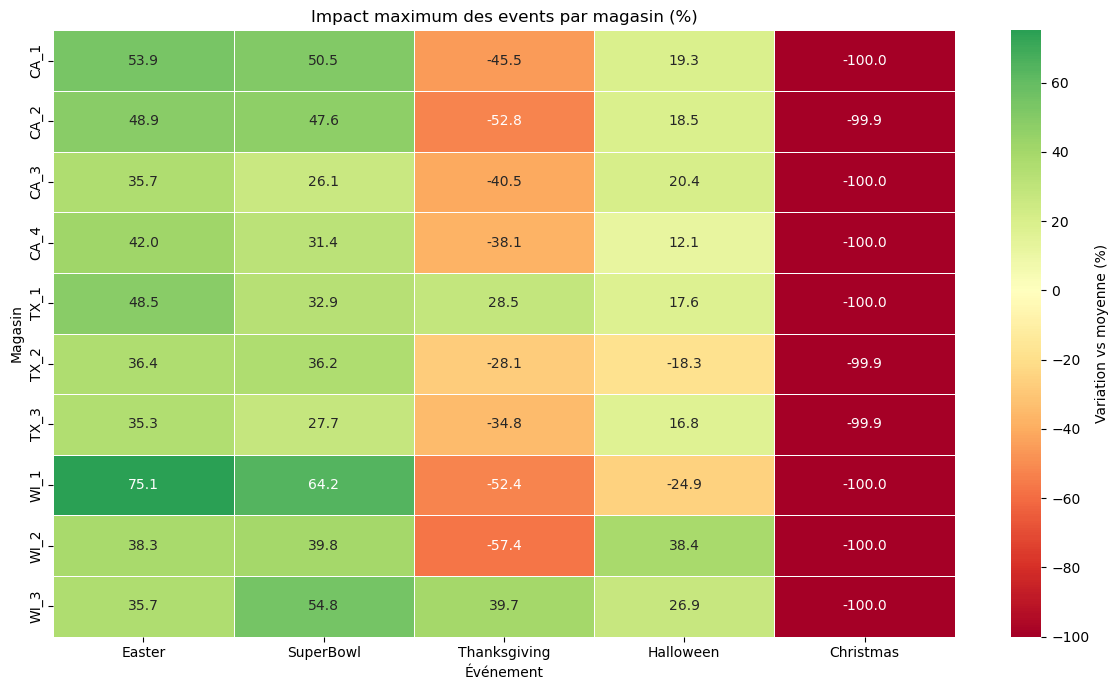

In [24]:
import seaborn as sns

events_cles = ["Easter", "SuperBowl", "Thanksgiving", "Halloween", "Christmas"]
offsets_cles = {
    "Easter"      : list(range(-7, 8)),
    "SuperBowl"   : list(range(-7, 8)),
    "Thanksgiving": list(range(-28, 8)),
    "Halloween"   : list(range(-28, 8)),
    "Christmas"   : list(range(-28, 8))
}

# pour chaque magasin et chaque event on récupère le pic max
heatmap_data = pd.DataFrame(index=sorted(daily_by_store.keys()), 
                             columns=events_cles)

for store in sorted(daily_by_store.keys()):
    for event in events_cles:
        offsets    = offsets_cles[event]
        variations = impact_event_magasin(store, event, offsets)
        idx_max    = np.argmax(np.abs(variations))
        heatmap_data.loc[store, event] = round(variations[idx_max], 1)

heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5,
            cbar_kws={"label": "Variation vs moyenne (%)"})
plt.title("Impact maximum des events par magasin (%)")
plt.xlabel("Événement")
plt.ylabel("Magasin")
plt.tight_layout()
plt.show()
 

### On interprète la heatmap

**Christmas (-100% pour tous les magasins)**
- Walmart est fermé le 25 décembre dans tous les états
- C'est le seul event qui impacte tous les magasins de façon identique
- Action : ne pas sur-stocker, anticiper la fermeture

**Easter (fort impact positif)**
- WI_1 est le magasin le plus sensible (+75%) 
- CA_1 et TX_1 suivent (+54%, +49%)
- CA_3 qui est pourtant le plus gros magasin réagit moins (+36%)
- Action : maximiser les stocks la veille dans tous les magasins, 
  en priorité WI_1 et CA_1

**SuperBowl (fort impact positif)**
- WI_1 encore le plus réactif (+64%)
- WI_3 très fort aussi (+55%)
- CA_3 le moins réactif (+26%)
- Action : stocker max la veille, surtout dans les magasins du Wisconsin

**Thanksgiving (comportements très différents selon les magasins)**
- WI_2 chute fortement (-57%)==>fermeture anticipée
- WI_1 chute aussi (-52%)
- WI_3 et TX_1 sont positifs (+40%, +29%)==> ces magasins profitent du weekend
- C'est l'event avec les comportements les plus hétérogènes
- Action : adapter la stratégie magasin par magasin

**Halloween (impact modéré)**
- WI_2 surperforme le plus (+38%)
- WI_3 aussi (+27%)
- TX_2 et WI_1 sont négatifs (-18%, -25%)==>ces magasins ne profitent pas d'Halloween
- Action : stocker tôt pour WI_2 et WI_3, pas de changement pour TX_2

**Conclusion générale**
- WI_1 est paradoxalement le magasin le plus sensible aux events 
  malgré ses faibles ventes globales
- CA_3 qui vend le plus est le moins réactif aux events
- Cela confirme qu'il faut analyser chaque magasin séparément 
  et ne pas appliquer une stratégie uniforme
- Ces résultats vont directement alimenter notre modèle de prévision 
  car la feature has_event aura un impact différent selon le magasin

# On passe à l'analyse des features 

Les features ont été choisies en s'appuyant sur l'analyse 
exploratoire réalisée précédemment.

**Identité du magasin**
- store_id_enc, state_id_enc : chaque magasin a son propre comportement
  comme montré dans la heatmap des événements. On encode en chiffres
  car le modèle ne comprend pas les textes comme "CA_3"

**Saisonnalité temporelle**
- dayofweek : les ventes varient selon le jour de la semaine
  (pic le weekend identifié dans l'analyse de FOODS_3_090)
- month : les ventes varient selon le mois
  (août et septembre sont les mois les plus forts)
- week_of_year : capture les variations hebdomadaires sur l'année

**Historique des ventes**
- lag_7 : ventes il y a 7 jours. Justifié par l'analyse des events
  qui montre que les pics arrivent souvent dans une fenêtre de 7 jours
- rolling_mean_7 : moyenne des 7 derniers jours pour capturer
  la tendance récente et lisser le bruit quotidien

**Features supprimées volontairement**
- sell_price : trop complexe à intégrer pour cette version
- lag_28, rolling_mean_28 : on garde simple avec lag_7 uniquement
- dept_id_enc : trop lourd, non pertinent pour l'analyse par magasin

In [41]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


dtype_dict = {'id':'category','item_id':'category','dept_id':'category',
              'cat_id':'category','store_id':'category','state_id':'category'}
df_sales = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv', dtype=dtype_dict)

meta_cols = ['id','item_id','dept_id','cat_id','store_id','state_id']
day_cols  = [c for c in df_sales.columns if c.startswith('d_')]

# on garde les 180 derniers jours car suffisant (lag max = 7)
df_sub  = df_sales[meta_cols + day_cols[-180:]].copy()
del df_sales

# format long
df_long = df_sub.melt(id_vars=meta_cols, var_name='d', value_name='sales')
df_long['sales'] = df_long['sales'].astype(np.int16)
del df_sub

# calendrier
df_cal  = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')
df_long = df_long.merge(
    df_cal[['d','date','month','wday','event_name_1','wm_yr_wk']],
    on='d', how='left')

# variables temporelles
df_long['date']         = pd.to_datetime(df_long['date'])
df_long['dayofweek']    = df_long['date'].dt.dayofweek.astype(np.int8)
df_long['week_of_year'] = df_long['date'].dt.isocalendar().week.astype(np.int8)
df_long['has_event']    = df_long['event_name_1'].notna().astype(np.int8)


df_long['store_id_enc'] = df_long['store_id'].astype('category').cat.codes.astype(np.int8)
df_long['state_id_enc'] = df_long['state_id'].astype('category').cat.codes.astype(np.int8)

# on fait un tri chronologique 
df_long = df_long.sort_values(['store_id','item_id','d']).reset_index(drop=True)

# lag_7 et rolling_mean_7 uniquement
df_long['lag_7']         = df_long.groupby(['item_id','store_id'])['sales'].shift(7)
g = df_long.groupby(['item_id','store_id'])
df_long['rolling_mean_7'] = g['sales'].shift(1).groupby(g.ngroup()).transform(
    lambda x: x.rolling(7, min_periods=1).mean())

for col in ['lag_7','rolling_mean_7']:
    df_long[col] = df_long[col].astype(np.float32) # j'ai pas mis float64 sinon mon pc va crasher

# suppression des NaN
df_model = df_long.dropna(subset=['lag_7','rolling_mean_7']).copy()
print('Feature engineering terminé:', df_model.shape)
print(df_model.head())

Feature engineering terminé: (5274770, 20)
                               id        item_id    dept_id   cat_id store_id  \
7   HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
8   HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
9   HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
10  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
11  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   

   state_id       d  sales       date  month  wday event_name_1  wm_yr_wk  \
7        CA  d_1769      1 2015-12-02     12     5          NaN     11544   
8        CA  d_1770      0 2015-12-03     12     6          NaN     11544   
9        CA  d_1771      0 2015-12-04     12     7          NaN     11544   
10       CA  d_1772      0 2015-12-05     12     1          NaN     11545   
11       CA  d_1773      0 2015-12-06     12     2          NaN     11545   

    day

## Feature Engineering — Résultat

Le dataset final contient 5 274 770 lignes.
Chaque ligne représente un produit dans un magasin à une date précise.

Par exemple :
- HOBBIES_1_001 dans CA_1 le 02/12/2015 --> 1 vente
- lag_7 = 0 --> ce produit n avait pas vendu il y a 7 jours
- rolling_mean_7 = 0.71 --> en moyenne 0.71 unité par jour sur les 7 derniers jours
- has_event = 0 --> pas d événement ce jour

Le dataset est propre et prêt pour la modélisation.

In [31]:
from sklearn.model_selection import train_test_split

# features qu'on a gardé
FEATURES = [
    'store_id_enc', 'state_id_enc',
    'month', 'week_of_year', 'dayofweek',
    'lag_7', 'rolling_mean_7'
]
TARGET = 'sales'

X = df_model[FEATURES]
y = df_model[TARGET]

# Contrairement au cours de ML classique on ne fait PAS :
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# car ce sont des séries temporelles
# un split aléatoire mélangerait les dates et le modèle verrait le futur
# pendant l entraînement ce qui fausserait complètement les résultats

# on coupe donc manuellement dans le temps :
# tout ce qui est avant cutoff = train (le passé)
# tout ce qui est après cutoff = test (le futur)
cutoff  = df_model['date'].max() - pd.Timedelta(days=28)
train   = df_model[df_model['date'] <= cutoff]
test    = df_model[df_model['date'] >  cutoff]

X_train = train[FEATURES]
X_test  = test[FEATURES]
y_train = train[TARGET]
y_test  = test[TARGET]

print(f"Train : {X_train.shape}  Test : {X_test.shape}")
print(f"Période train : {train['date'].min()} : {train['date'].max()}")
print(f"Période test  : {test['date'].min()} : {test['date'].max()}")

Train : (4421050, 7)  Test : (853720, 7)
Période train : 2015-12-02 00:00:00 : 2016-04-24 00:00:00
Période test  : 2016-04-25 00:00:00 : 2016-05-22 00:00:00


on apprend bien sur les 28 derniers jours 

on passe à l'implémentation des modèles ( on avait vu que lightgbm, arbre de décision et régression étaient performants et adaptés à notre situation) mais on réentraine que eux ici pour avoir un notebook propre)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [33]:

# MODÈLE 1 : RÉGRESSION LINÉAIRE
# Pipeline + StandardScaler cours ML

steps_rl = [("scaler", StandardScaler()), ("model", LinearRegression())]
p_rl     = Pipeline(steps_rl)
p_rl.fit(X_train, y_train)
pred_rl  = p_rl.predict(X_test)

mae_rl  = mean_absolute_error(y_test, pred_rl)
rmse_rl = np.sqrt(mean_squared_error(y_test, pred_rl))
mape_rl = np.mean(np.abs((y_test.values - pred_rl) / (y_test.values + 1))) * 100
print(f"Regression Lineaire   MAE: {mae_rl:.2f} | RMSE: {rmse_rl:.2f} | MAPE: {mape_rl:.2f}%")

Regression Lineaire   MAE: 1.05 | RMSE: 2.09 | MAPE: 50.68%


en moyenne on se trompe d 1 unité par produit par jour MAE --> 1.05

In [35]:
# MODÈLE 2 : ARBRE DE DÉCISION avec GridSearch pour trouver meilleur hyperparamètre
steps_dt      = [("scaler", StandardScaler()), ("model", DecisionTreeRegressor())]
p_dt          = Pipeline(steps_dt)
parameters_dt = {
    "model__max_depth"        : [3, 5, 8, 10, 15],
    "model__min_samples_leaf" : [1, 2, 5, 10]
}
grid_dt = GridSearchCV(p_dt, param_grid=parameters_dt,
                       cv=5, scoring="neg_mean_squared_error")
grid_dt.fit(X_train, y_train)
print("Meilleurs params Arbre :", grid_dt.best_params_)
print("Meilleur score CV :", grid_dt.best_score_)
pred_dt = grid_dt.predict(X_test)

mae_dt  = mean_absolute_error(y_test, pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
mape_dt = np.mean(np.abs((y_test.values - pred_dt) / (y_test.values + 1))) * 100
print(f"Arbre de Decision     MAE: {mae_dt:.2f} | RMSE: {rmse_dt:.2f} | MAPE: {mape_dt:.2f}%")

Meilleurs params Arbre : {'model__max_depth': 8, 'model__min_samples_leaf': 5}
Meilleur score CV : -4.5255961189203076
Arbre de Decision     MAE: 1.04 | RMSE: 2.06 | MAPE: 50.51%


In [38]:
# MODÈLE 3 : LIGHTGBM
lgbm = lgb.LGBMRegressor(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)
pred_lgbm = lgbm.predict(X_test)

mae_lgbm  = mean_absolute_error(y_test, pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, pred_lgbm))
mape_lgbm = np.mean(np.abs((y_test.values - pred_lgbm) / (y_test.values + 1))) * 100
print(f"LightGBM              MAE: {mae_lgbm:.2f} | RMSE: {rmse_lgbm:.2f} | MAPE: {mape_lgbm:.2f}%")


# TABLEAU RÉCAPITULATIF


resultats = pd.DataFrame({
    "Modèle" : ["Regression Lineaire", "Arbre de Decision", "LightGBM"],
    "MAE"    : [round(mae_rl, 2), round(mae_dt, 2), round(mae_lgbm, 2)],
    "RMSE"   : [round(rmse_rl, 2), round(rmse_dt, 2), round(rmse_lgbm, 2)],
    "MAPE%"  : [round(mape_rl, 2), round(mape_dt, 2), round(mape_lgbm, 2)]
}).sort_values("RMSE")

print("TABLEAU RÉCAPITULATIF")
print(resultats.to_string(index=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 384
[LightGBM] [Info] Number of data points in the train set: 4421050, number of used features: 7
[LightGBM] [Info] Start training from score 1.321420
LightGBM              MAE: 1.04 | RMSE: 2.04 | MAPE: 50.42%
TABLEAU RÉCAPITULATIF
             Modèle  MAE  RMSE  MAPE%
           LightGBM 1.04  2.04  50.42
  Arbre de Decision 1.04  2.06  50.51
Regression Lineaire 1.05  2.09  50.68


l'écart entre LightGBM et la Régression Linéaire est de seulement 
0.01 MAE, ce qui est négligeable.

Conformément aux recommandations du professeur, nous choisissons 
la Régression Linéaire car :
- Elle est simple et interprétable
- Ses performances sont quasi identiques aux modèles complexes
- Elle peut être facilement expliquée lors de la soutenance

### Importance des features

L'arbre de décision permet d'identifier quelles features sont les plus importantes pour la prévision des ventes. On avait effectué des hypothèses mais maitenant qu'on a choisit le modèle on peut confirmer tout cela 

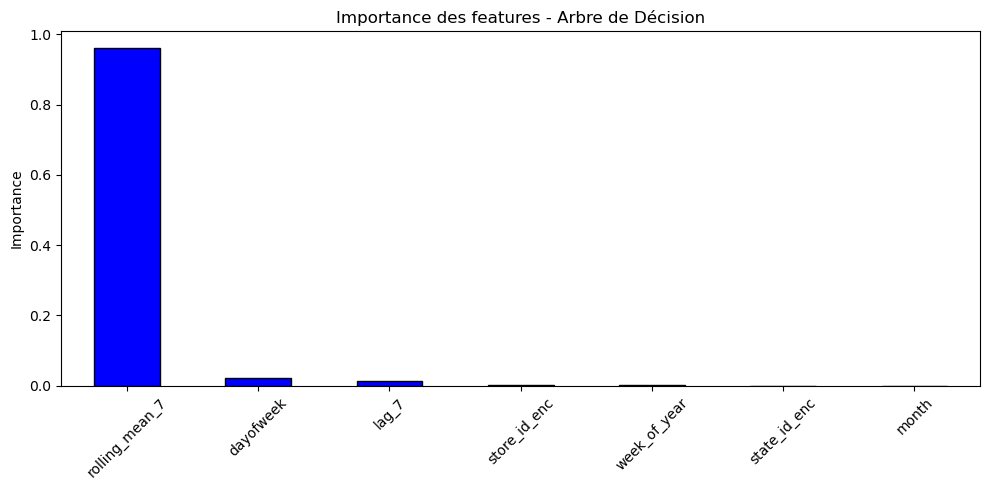

 Top features :
rolling_mean_7    0.960434
dayofweek         0.022222
lag_7             0.013048
store_id_enc      0.002584
week_of_year      0.001419
state_id_enc      0.000160
month             0.000133
dtype: float64


In [40]:
importances = pd.Series(
    grid_dt.best_estimator_.named_steps["model"].feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

importances.plot(kind="bar", color="blue",
                 edgecolor="black", figsize=(10, 5))
plt.title("Importance des features - Arbre de Décision")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(" Top features :")
print(importances)

je veux avoir une idée du réel vs prédit 

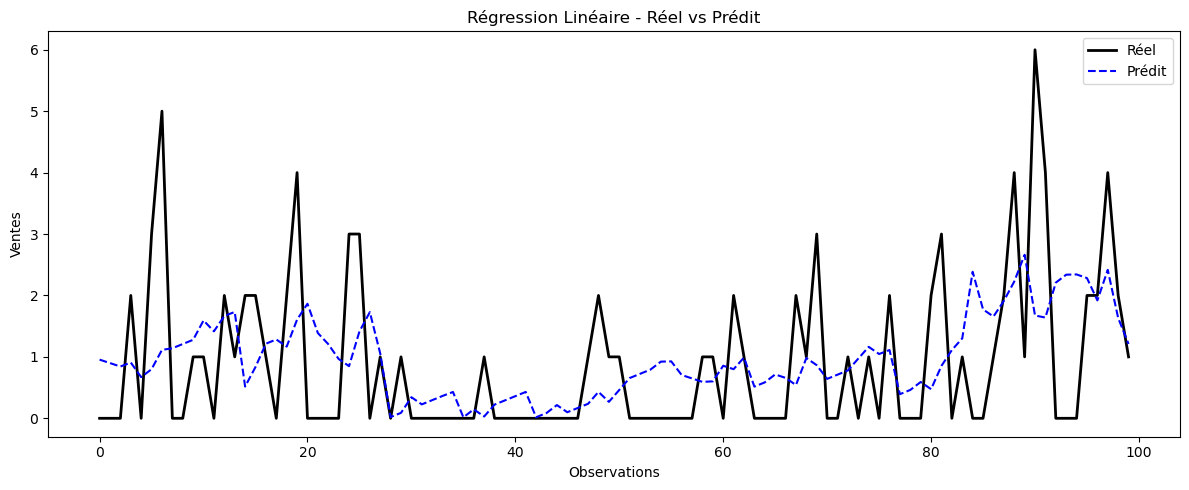

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label="Réel", color="black", linewidth=2)
plt.plot(pred_rl[:100], label="Prédit", color="blue", linestyle="dashed")
plt.title("Régression Linéaire - Réel vs Prédit")
plt.xlabel("Observations")
plt.ylabel("Ventes")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# corrélation de toutes les features avec les ventes
corr = df_model[FEATURES + ['sales']].corr()['sales'].sort_values(ascending=False)
print(corr)

sales             1.000000
rolling_mean_7    0.798681
lag_7             0.696426
dayofweek         0.040747
state_id_enc     -0.006993
store_id_enc     -0.011565
month            -0.012925
week_of_year     -0.014386
Name: sales, dtype: float64


In [44]:
corr_event = df_model[['sales', 'has_event']].corr()['sales']
print(corr_event)

sales        1.00000
has_event   -0.00503
Name: sales, dtype: float64


La corrélation globale de has_event est quasi nulle car les jours d'events sont minoritaires dans le dataset. Mais notre analyse approfondie montre des impacts locaux significatifs allant jusqu'à +40% pour Easter. C'est pourquoi on a gardé l'analyse des events séparément c'est pour cela que j'avais tenu à vérifier la corrélation et approfondir les events

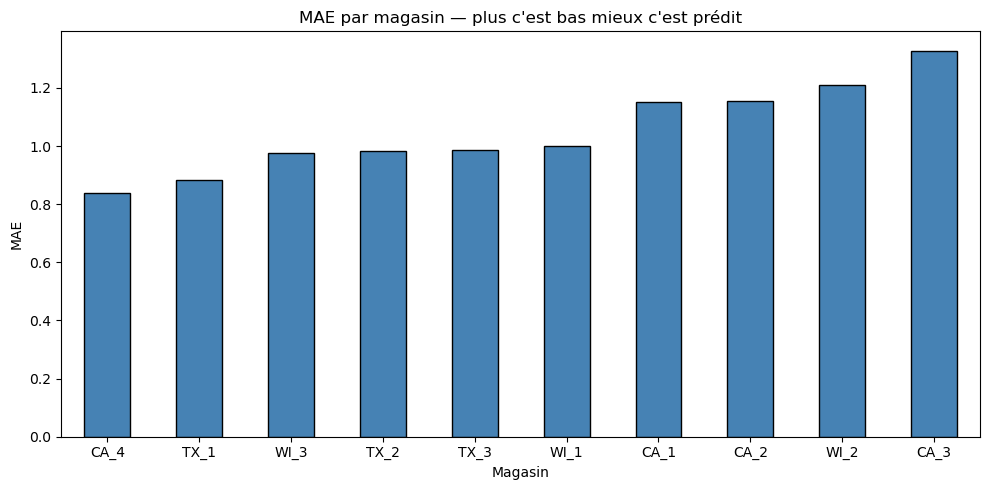


Magasin le mieux prédit : CA_4
Magasin le moins bien prédit : CA_3


In [47]:
test_avec_magasin          = test.copy()
test_avec_magasin['pred']  = pred_rl
test_avec_magasin['erreur'] = abs(test_avec_magasin['sales'] - test_avec_magasin['pred'])

# MAE par magasin
mae_par_magasin = test_avec_magasin.groupby('store_id')['erreur'].mean().sort_values()


mae_par_magasin.plot(kind='bar', color='steelblue',
                     edgecolor='black', figsize=(10, 5))
plt.title("MAE par magasin — plus c'est bas mieux c'est prédit")
plt.xlabel("Magasin")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nMagasin le mieux prédit :", mae_par_magasin.index[0])
print("Magasin le moins bien prédit :", mae_par_magasin.index[-1])

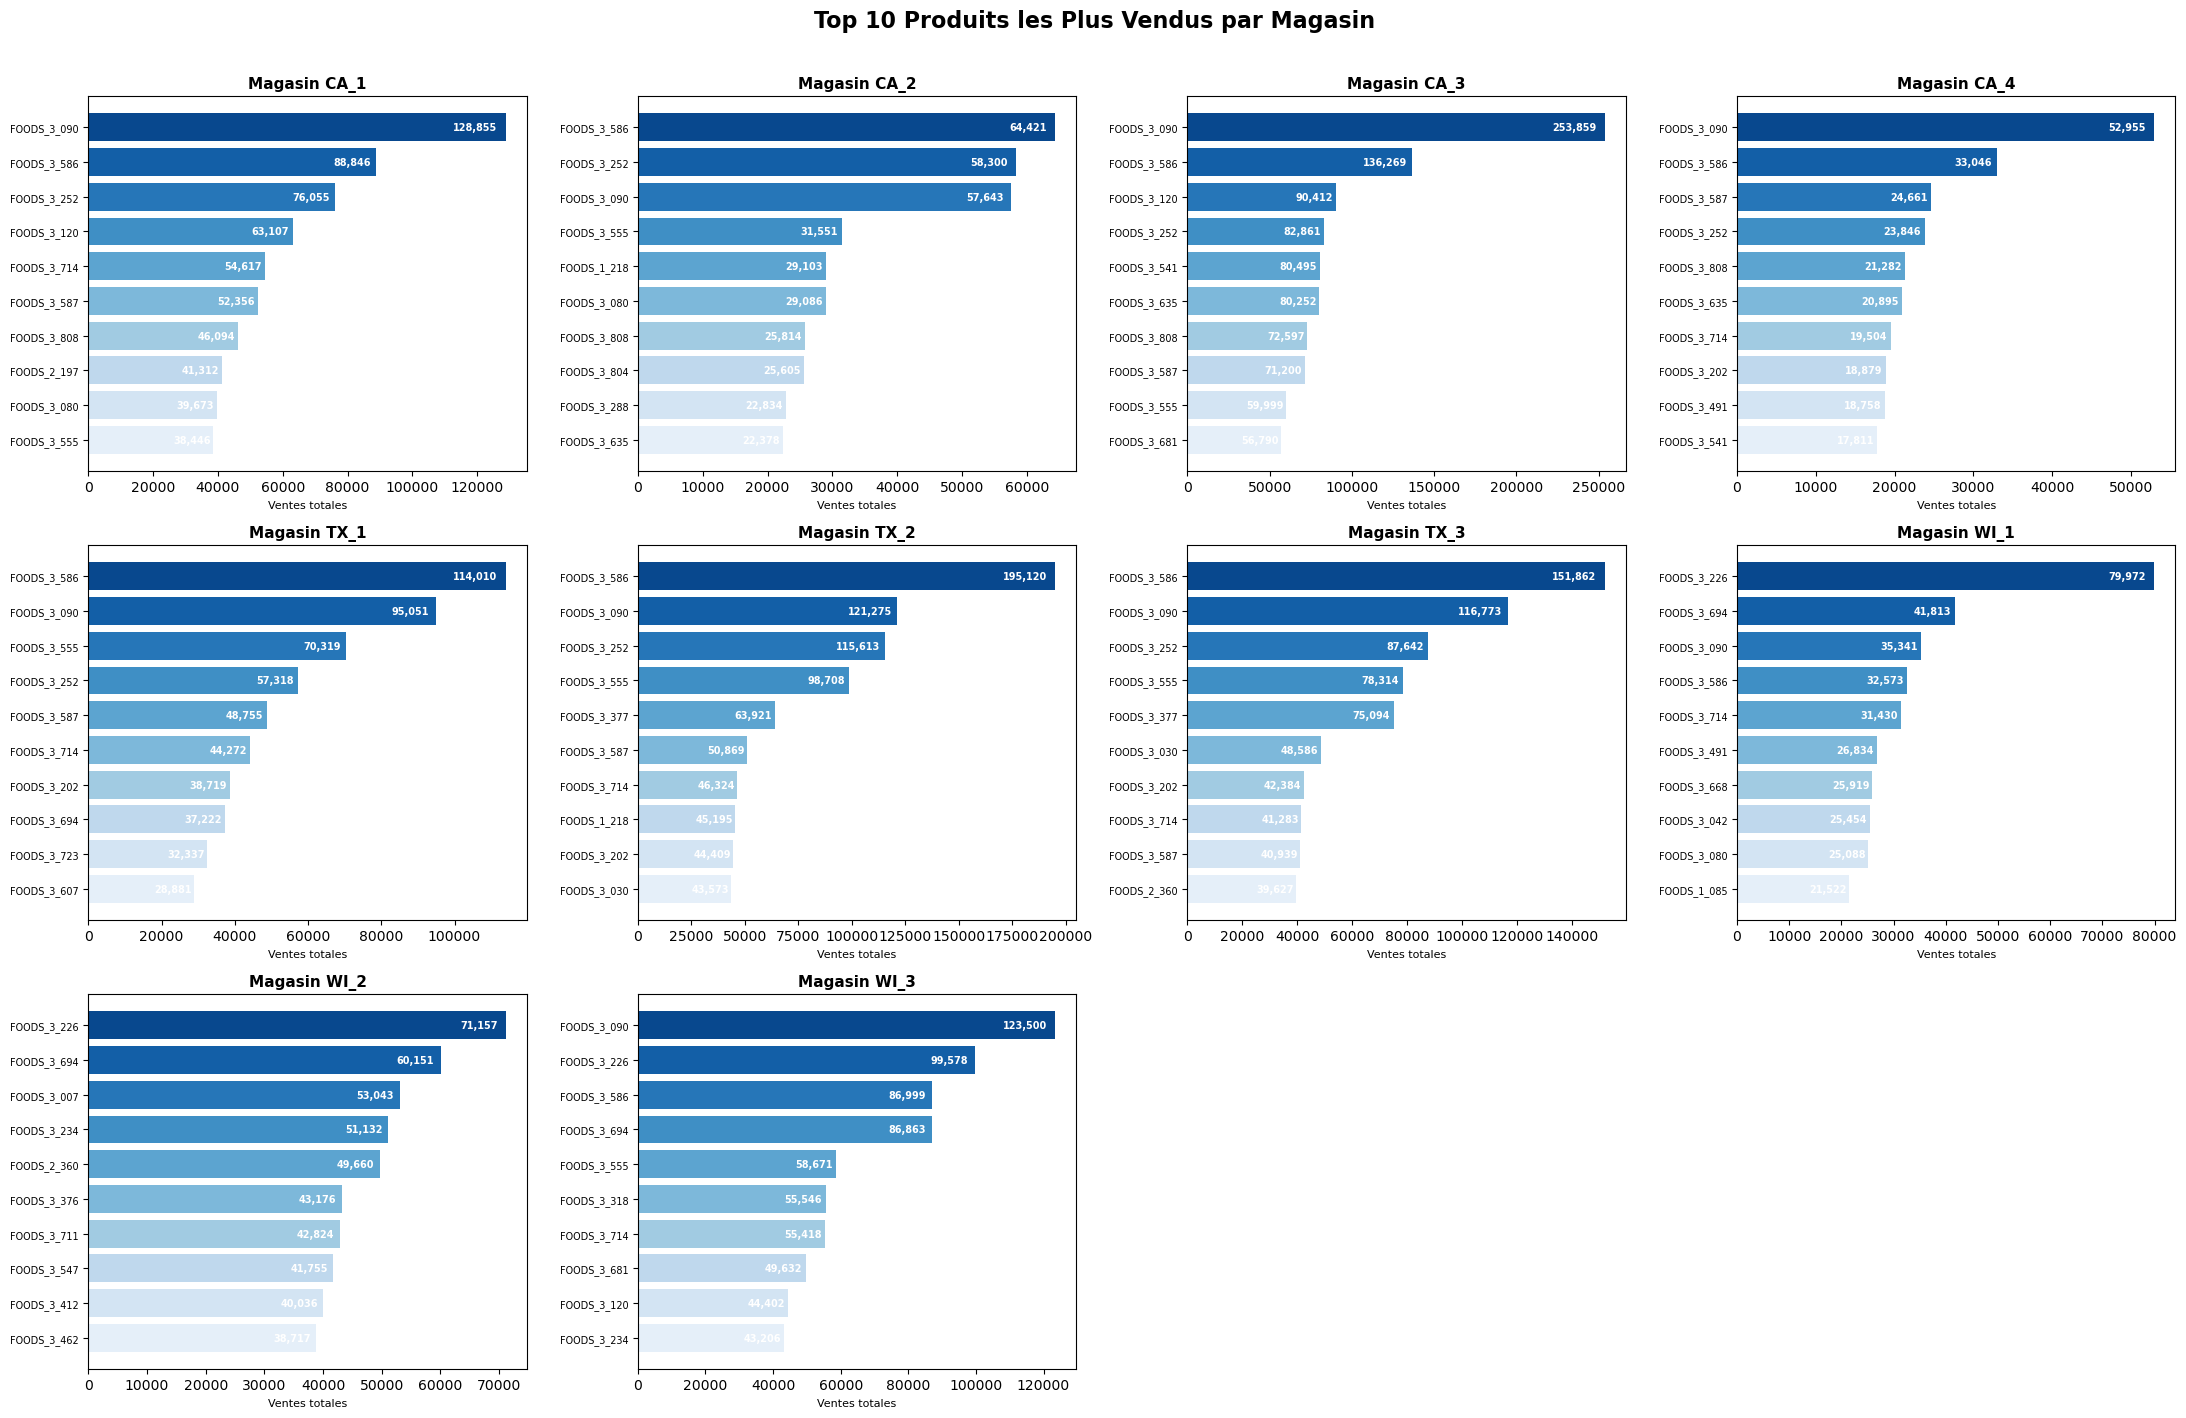

In [48]:
import seaborn as sns

# Total des ventes par produit
sales['total_sales'] = sales[day_cols].sum(axis=1)

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

stores = sorted(sales['store_id'].unique())

for i, store in enumerate(stores):
    ax = axes[i]
    store_data = sales[sales['store_id'] == store]
    top10 = store_data.nlargest(10, 'total_sales')[['item_id', 'total_sales']]
    
    colors = sns.color_palette("Blues_r", 10)
    bars = ax.barh(top10['item_id'], top10['total_sales'], color=colors)
    
    for bar, val in zip(bars, top10['total_sales']):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height()/2,
                f'{int(val):,}', va='center', ha='right', fontsize=7, color='white', fontweight='bold')
    
    ax.set_title(f'Magasin {store}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Ventes totales', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

for j in range(len(stores), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Produits les Plus Vendus par Magasin', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top10_produits_magasin.png', dpi=150, bbox_inches='tight')
plt.show()

## Prévision de la semaine prochaine par magasin

On utilise le modèle entraîné pour prédire les ventes 
des 7 prochains jours par magasin.
On croise ensuite avec les events à venir pour alerter 
Sophie Martin sur les risques de sur ou sous-stock.

In [58]:
# PRÉVISION SEMAINE PROCHAINE PAR MAGASIN

derniere_date = df_mag['date'].max()
dates_futures = [derniere_date + pd.Timedelta(days=i) for i in range(1, 8)]

previsions = []

for store in df_mag['store_id'].unique():
    store_enc  = df_mag[df_mag['store_id'] == store]['store_id_enc'].iloc[0]
    moyenne_7j = df_mag[df_mag['store_id'] == store]['sales'].tail(7).mean()

    for date in dates_futures:
        previsions.append({
            'store_id'       : store,
            'date'           : date,
            'store_id_enc'   : store_enc,
            'dayofweek'      : date.weekday(),
            'month'          : date.month,
            'lag_7'          : moyenne_7j,
            'rolling_mean_7' : moyenne_7j
        })

df_prev             = pd.DataFrame(previsions)
df_prev['pred']     = p_mag.predict(df_prev[FEATURES_MAG])
df_prev.loc[df_prev['pred'] < 0, 'pred'] = 0

print(df_prev[['store_id', 'date', 'pred']])

   store_id       date         pred
0      CA_1 2016-05-23  4402.393777
1      CA_1 2016-05-24  4508.473109
2      CA_1 2016-05-25  4614.552440
3      CA_1 2016-05-26  4720.631772
4      CA_1 2016-05-27  4826.711104
..      ...        ...          ...
65     WI_3 2016-05-25  3777.017782
66     WI_3 2016-05-26  3883.097113
67     WI_3 2016-05-27  3989.176445
68     WI_3 2016-05-28  4095.255777
69     WI_3 2016-05-29  4201.335109

[70 rows x 3 columns]


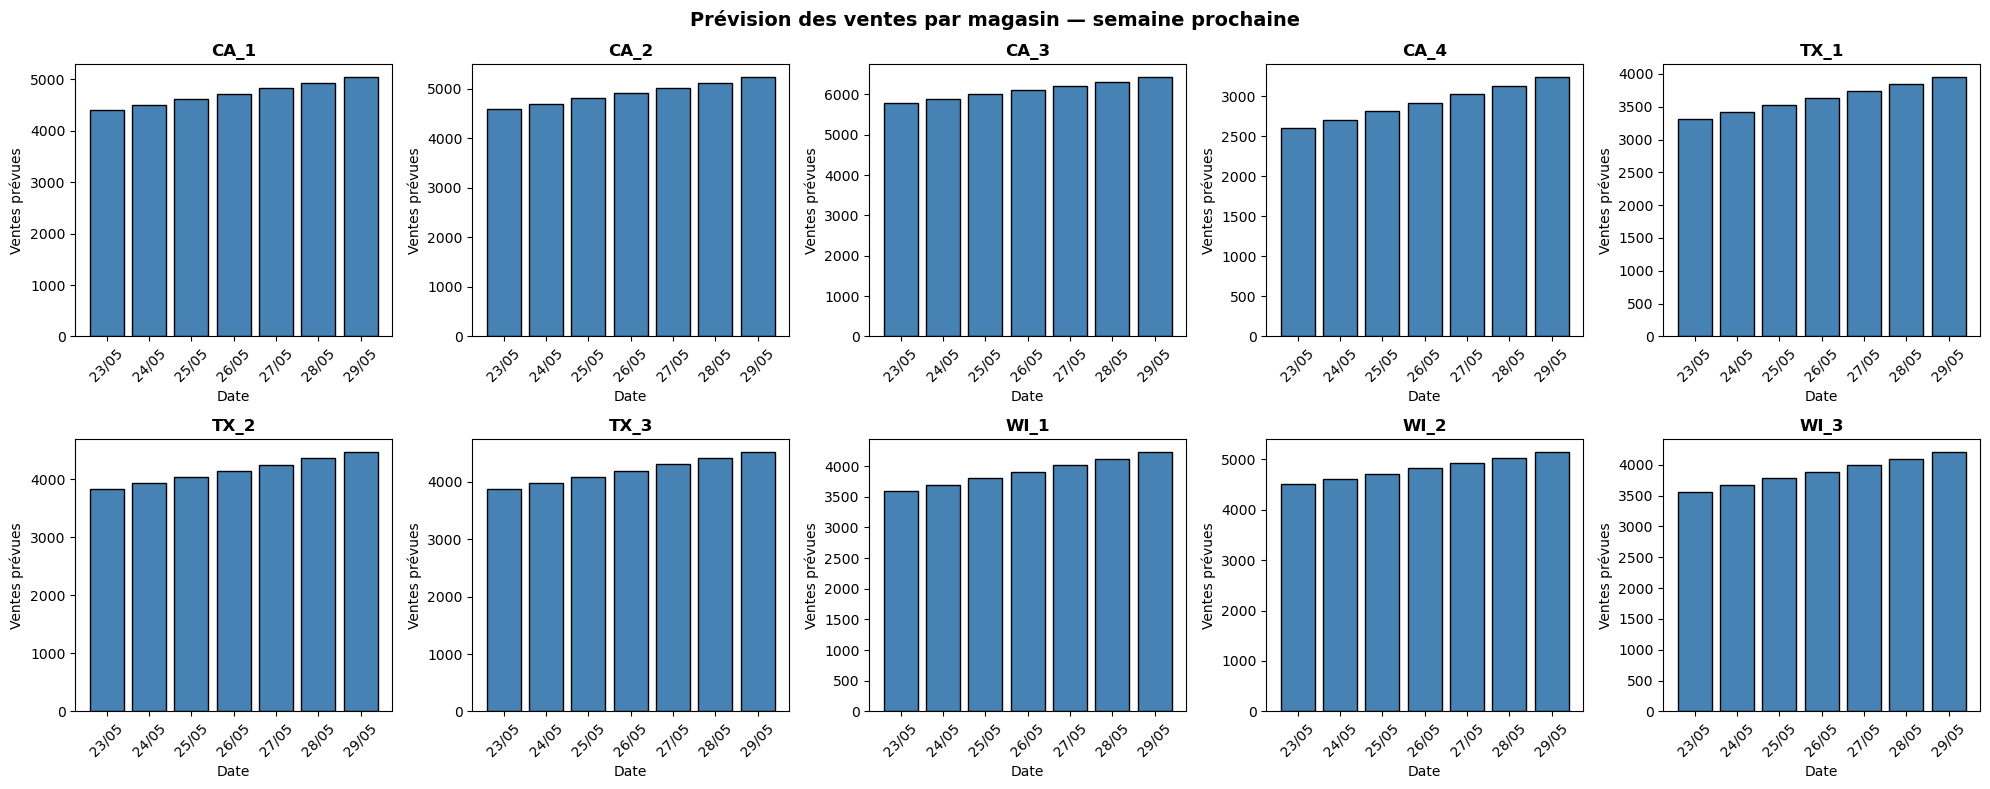

In [59]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, store in enumerate(sorted(df_prev['store_id'].unique())):
    data = df_prev[df_prev['store_id'] == store]
    axes[i].bar(data['date'].dt.strftime('%d/%m'),
                data['pred'],
                color='steelblue',
                edgecolor='black')
    axes[i].set_title(store, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Ventes prévues")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Prévision des ventes par magasin — semaine prochaine",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
# alerte events pour la semaine prochaine
alertes = {
    "Easter"       : {"impact": "+40%", "timing": "stocker la veille"},
    "SuperBowl"    : {"impact": "+35%", "timing": "stocker la veille"},
    "Thanksgiving" : {"impact": "-40% jour J", "timing": "stocker 3 semaines avant"},
    "Halloween"    : {"impact": "+15%", "timing": "stocker 4 semaines avant"},
    "Christmas"    : {"impact": "-100% jour J", "timing": "ne pas sur-stocker"}
}

# vérifier si un event tombe dans les 28 prochains jours
dates_check = [derniere_date + pd.Timedelta(days=i) for i in range(1, 29)]

events_a_venir = calendar[
    (pd.to_datetime(calendar['date']).isin(dates_check)) &
    (calendar['event_name_1'].isin(alertes.keys()))
][['date', 'event_name_1']]

if len(events_a_venir) == 0:
    print("Aucun event majeur dans les 28 prochains jours")
else:
    for _, row in events_a_venir.iterrows():
        event = row['event_name_1']
        print(f"ALERTE : {event} le {row['date']}")
        print(f"  Impact attendu : {alertes[event]['impact']}")
        print(f"  Action : {alertes[event]['timing']}")

Aucun event majeur dans les 28 prochains jours
